In [1]:
import torch

torch.__version__

'2.6.0'

In [8]:
# get data
w = 0.7
b = 0.3

X = torch.arange(0,1,0.02).unsqueeze(dim=1)

y = w*X + b
X[:2], y[:2]

(tensor([[0.0000],
         [0.0200]]),
 tensor([[0.3000],
         [0.3140]]))

In [34]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, shuffle=False)

len(X_train), len(X_test)

(37, 13)

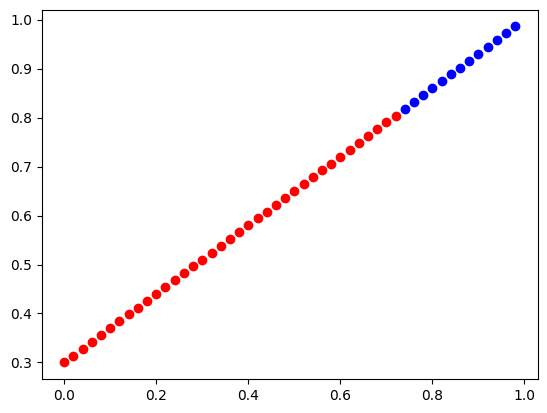

In [35]:
# visualize
import matplotlib.pyplot as plt

plt.scatter(X_train,y_train, c="r")
plt.scatter(X_test,y_test, c="b")


In [43]:
from torch import nn

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,  dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,  dtype=torch.float), requires_grad=True)
        
    def forward(self, input):
        return self.weight * input + self.bias

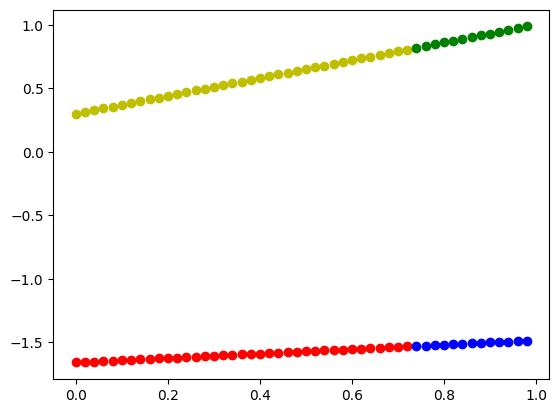

In [52]:
model_1 = LinearModel()

# visualize
import matplotlib.pyplot as plt

plt.scatter(X_train,y_train,  c="y")
plt.scatter(X_test,y_test,  c="g")


plt.scatter(X_train,model_1(X_train).detach().numpy(), c="r")
plt.scatter(X_test,model_1(X_test).detach().numpy(), c="b")

In [49]:
model_1(X_train).detach().numpy()

array([[0.6919953 ],
       [0.7247058 ],
       [0.7574163 ],
       [0.7901268 ],
       [0.8228373 ],
       [0.8555478 ],
       [0.8882583 ],
       [0.9209688 ],
       [0.9536792 ],
       [0.98638976],
       [1.0191002 ],
       [1.0518107 ],
       [1.0845212 ],
       [1.1172316 ],
       [1.1499422 ],
       [1.1826527 ],
       [1.2153631 ],
       [1.2480736 ],
       [1.2807841 ],
       [1.3134947 ],
       [1.3462051 ],
       [1.3789157 ],
       [1.4116261 ],
       [1.4443367 ],
       [1.4770471 ],
       [1.5097575 ],
       [1.5424681 ],
       [1.5751785 ],
       [1.607889  ],
       [1.6405995 ],
       [1.67331   ],
       [1.7060206 ],
       [1.7387309 ],
       [1.7714415 ],
       [1.804152  ],
       [1.8368626 ],
       [1.8695731 ]], dtype=float32)

In [65]:
# Training loop
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01)
epochs = 1000
for epoch in range(epochs):
    # train
    model_1.train()
    preds = model_1(X_train)   
    loss = loss_fn(preds, y_train) 
    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step()
    
    #eval
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)
        
        if epoch%10 == 0:
            print(f"Train loss : {loss} |  Test Loss : {test_loss} and Epooch : {epoch}")
        
        

Train loss : 0.022922271862626076 |  Test Loss : 0.017926793545484543 and Epooch : 0
Train loss : 0.008987733162939548 |  Test Loss : 0.022518685087561607 and Epooch : 10
Train loss : 0.005986656062304974 |  Test Loss : 0.014462714083492756 and Epooch : 20
Train loss : 0.002977471798658371 |  Test Loss : 0.007123933173716068 and Epooch : 30
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 40
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 50
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 60
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 70
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 80
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 90
Train loss : 0.003526698099449277 |  Test Loss : 0.005892143584787846 and Epooch : 100
Train loss : 0.003526698099449277 |  Test Loss : 0.005

In [66]:
model_1.state_dict()

OrderedDict([('weight', tensor([0.7074])), ('bias', tensor([0.3009]))])

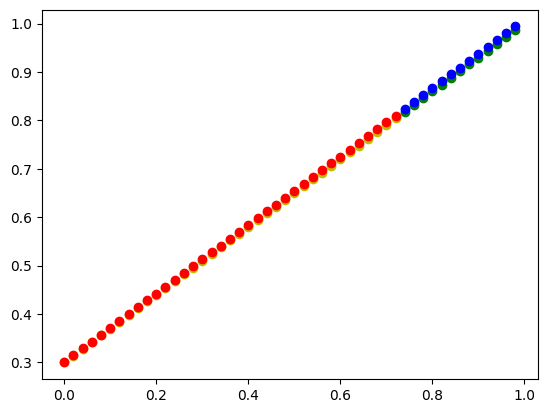

In [67]:

plt.scatter(X_train,y_train,  c="y")
plt.scatter(X_test,y_test,  c="g")


plt.scatter(X_train,model_1(X_train).detach().numpy(), c="r")
plt.scatter(X_test,model_1(X_test).detach().numpy(), c="b")

In [69]:
# save the model
from pathlib import Path

model_path = Path("model")

model_path.mkdir()


In [70]:
model_name = "my_linear_model.pt"
torch.save(model_1.state_dict(), model_path/model_name)

In [71]:
model_2 =  LinearModel()

model_2.state_dict()

OrderedDict([('weight', tensor([0.2870])), ('bias', tensor([-0.1522]))])

In [72]:
model_2.load_state_dict(torch.load(model_path/model_name))

<All keys matched successfully>

In [73]:
model_2.state_dict()

OrderedDict([('weight', tensor([0.7074])), ('bias', tensor([0.3009]))])